### 분석 내용: Driving Style - Tire Pressure 에 따른 주행전력 효율 분석

#### 왜 필요한가


#### 무엇을 예측하나


#### 어디에 쓰나


#### 누가 쓰나



In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels


In [42]:
# warning 무시
import warnings
warnings.filterwarnings('ignore')

In [43]:
df = pd.read_csv('./datas_ml/ev_energy_consumption.csv')
df.head()

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883


속도 / 하중 / 외기온 / 냉난방 / 경사도 / 배터리온도 / 운전습관 / 타이어공기압 / 주행거리 -> 100km당 소비전력

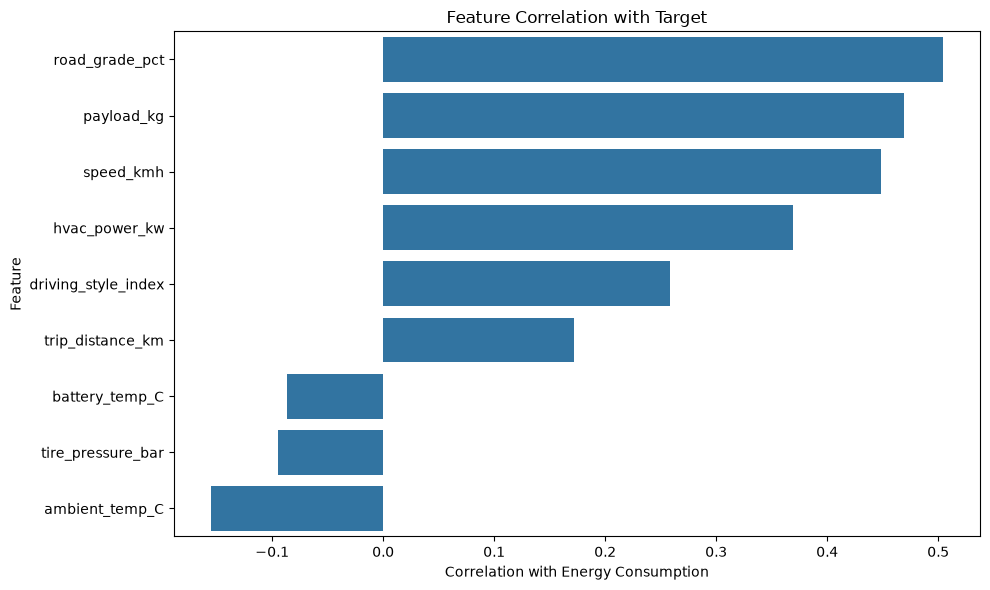

In [44]:
target = 'energy_consumption_kwhper100km'

corr_target = (
    df.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=corr_target.values,
    y=corr_target.index
)

plt.xlabel('Correlation with Energy Consumption')
plt.ylabel('Feature')
plt.title('Feature Correlation with Target')

plt.tight_layout()
plt.show()

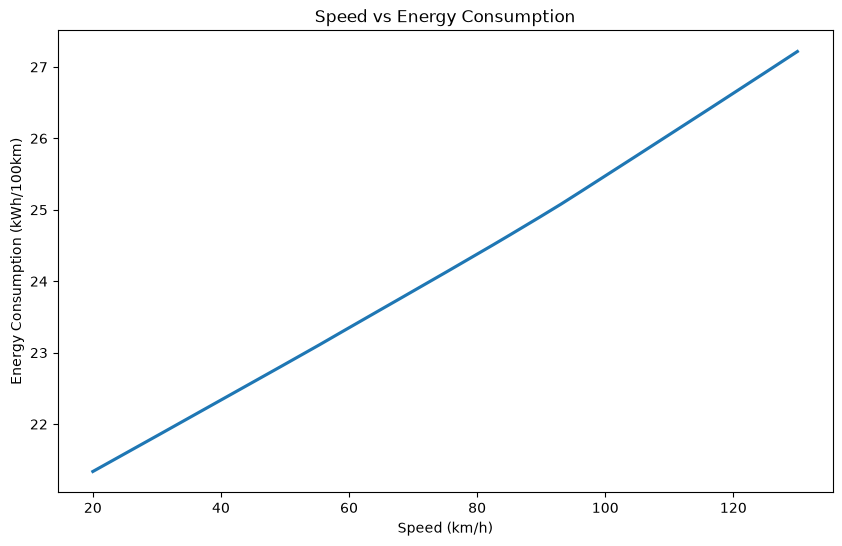

In [45]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='speed_kmh',
    y='energy_consumption_kwhper100km',
    scatter=False,
    lowess=True
)

plt.xlabel('Speed (km/h)')
plt.ylabel('Energy Consumption (kWh/100km)')
plt.title('Speed vs Energy Consumption')

plt.show()

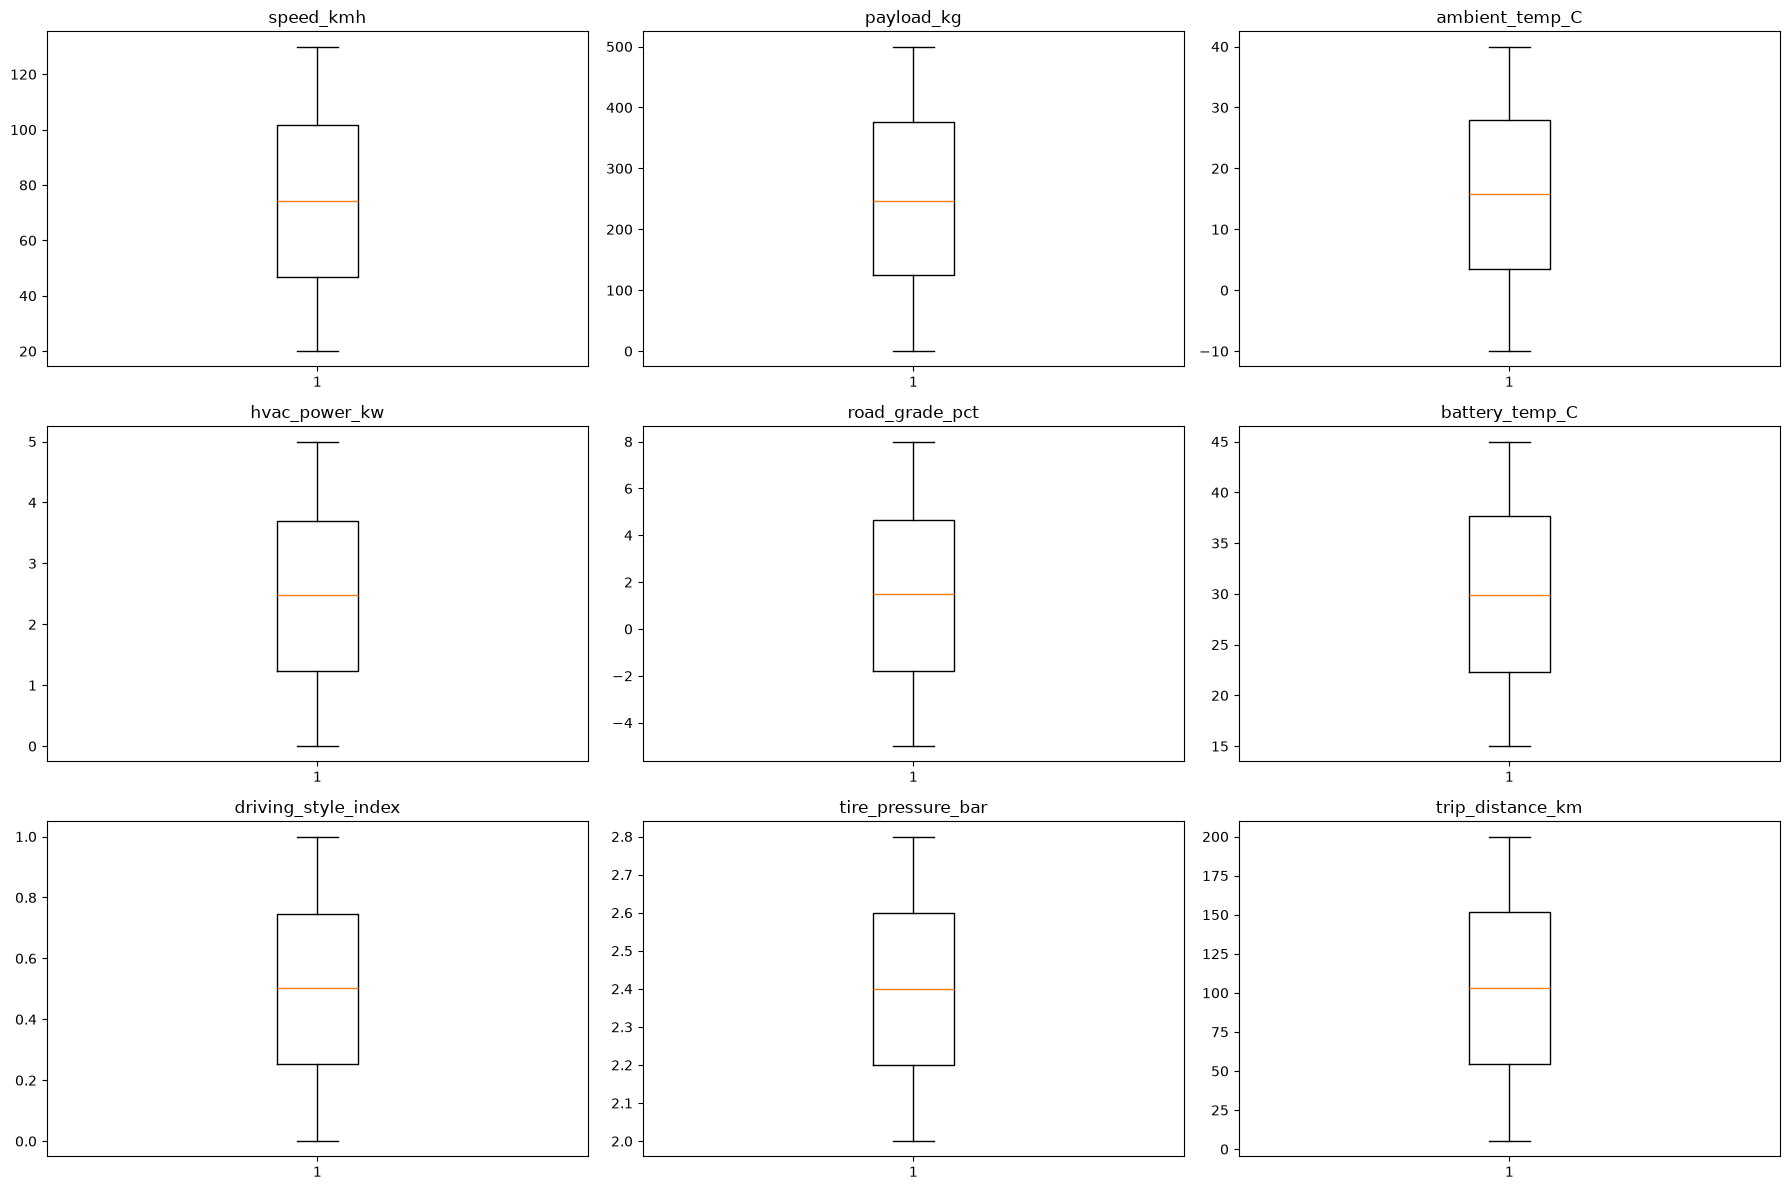

In [46]:
import matplotlib.pyplot as plt

features = df.drop(
    columns=['energy_consumption_kwhper100km']
).columns

fig, axs = plt.subplots(3, 3, figsize=(18, 12))
axs = axs.flatten()

for i, col in enumerate(features):
    axs[i].boxplot(df[col])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

In [47]:
import numpy as np
import pandas as pd

def recommend_speed(
    model,
    distance,
    road_grade,
    payload,
    ambient_temp,
    hvac_power,
    battery_temp,
    driving_style,
    tire_pressure,
    alpha=0.5
):
    
    speeds = np.arange(20, 131, 1)

    results = []

    for speed in speeds:

        X = pd.DataFrame([{
            'speed_kmh': speed,
            'payload_kg': payload,
            'ambient_temp_C': ambient_temp,
            'hvac_power_kw': hvac_power,
            'road_grade_pct': road_grade,
            'battery_temp_C': battery_temp,
            'driving_style_index': driving_style,
            'tire_pressure_bar': tire_pressure,
            'trip_distance_km': distance
        }])

        # kWh / 100 km
        consumption_per_100km = model.predict(X)[0]

        # 실제 구간에서 소비되는 총 에너지
        total_energy = consumption_per_100km * distance / 100

        # 예상 주행시간
        travel_time = distance / speed

        results.append([
            speed,
            consumption_per_100km,
            total_energy,
            travel_time
        ])

    result_df = pd.DataFrame(
        results,
        columns=[
            'speed',
            'consumption_per_100km',
            'total_energy',
            'travel_time'
        ]
    )

    # Min-Max normalization
    result_df['energy_score'] = (
        result_df['total_energy'] - result_df['total_energy'].min()
    ) / (
        result_df['total_energy'].max() - result_df['total_energy'].min()
    )

    result_df['time_score'] = (
        result_df['travel_time'] - result_df['travel_time'].min()
    ) / (
        result_df['travel_time'].max() - result_df['travel_time'].min()
    )

    # 최종 목적함수
    result_df['cost'] = (
        alpha * result_df['energy_score']
        + (1 - alpha) * result_df['time_score']
    )

    best = result_df.loc[result_df['cost'].idxmin()]

    return best, result_df

비선형 관계를 잘 잡을 수 있다.
EV 에너지 소비는 속도, 경사도, 온도 같은 변수와 항상 직선 관계를 가지지 않는다. Random Forest는 별도의 식을 가정하지 않고 이런 비선형 패턴을 학습할 수 있다.
feature 간 상호작용을 자동으로 반영할 수 있다.
예를 들어 같은 속도라도 경사도가 다르면 에너지 소비가 달라질 수 있다.
$$ Energy = f(speed,\ road\ grade,\ payload,\ldots) $$

Random Forest는 speed × road_grade 같은 interaction term을 직접 만들어주지 않아도 tree split을 통해 이런 관계를 학습할 수 있다.

전처리가 비교적 간단하다.
현재 feature들이 모두 수치형이고 결측치도 거의 없기 때문에 Random Forest에 바로 넣기 좋다. 특히 StandardScaler 같은 scaling이 필요하지 않다.

                 Raw Data
                    ↓
                  EDA
                    ↓
             Train / Test Split
                    ↓
        ┌───────────┼───────────┐
        ↓           ↓           ↓
      Linear       RF         XGBoost
    Regression      │            │
        │     RandomizedCV  RandomizedCV
        │           │            │
        └───────────┼────────────┘
                    ↓
             RMSE / MAE / R²
                    ↓
             Best Model 선택
                    ↓
        Energy Consumption Model
                    ↓
         Energy-Time Optimization
                    ↓
         Recommended Driving Speed

### Linear Regression (baseline)

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 모델 생성
lr_model = LinearRegression()

# 학습
lr_model.fit(X_train, y_train)

# 예측
lr_pred = lr_model.predict(X_test)

# 평가
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("=== Linear Regression ===")
print(f"RMSE : {lr_rmse:.4f}")
print(f"MAE  : {lr_mae:.4f}")
print(f"R²   : {lr_r2:.4f}")

=== Linear Regression ===
RMSE : 0.9966
MAE  : 0.7942
R²   : 0.9293


## Random Forest + RandomizedSearchCV

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# 기본 모델
rf = RandomForestRegressor(
    random_state=2026,
    n_jobs=-1
)

# 탐색할 hyperparameter
rf_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [None, 10, 15, 20, 30],
    'min_samples_split': [2, 4, 6, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.7, 1.0]
}

# Randomized Search
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=2026,
    n_jobs=-1,
    verbose=1
)

# 학습 + CV
rf_search.fit(X_train, y_train)

# 최적 모델
rf_model = rf_search.best_estimator_

print("Best Parameters:")
print(rf_search.best_params_)

print()

print(
    "Best CV RMSE:",
    -rf_search.best_score_
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/aiuser/gg1th_ml_basic/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aiuser/gg1th_ml_basic/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aiuser/gg1th_ml_basic/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aiuser/gg1th_ml_basic/.venv/lib/py

Best Parameters:
{'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': None}

Best CV RMSE: 1.2170039672910011


In [56]:
rf_pred = rf_model.predict(X_test)

rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("=== Random Forest ===")
print(f"RMSE : {rf_rmse:.4f}")
print(f"MAE  : {rf_mae:.4f}")
print(f"R²   : {rf_r2:.4f}")

=== Random Forest ===
RMSE : 1.1932
MAE  : 0.9484
R²   : 0.8986


In [58]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print(rf_importance)

               Feature  Importance
4       road_grade_pct    0.259106
1           payload_kg    0.230840
0            speed_kmh    0.201943
3        hvac_power_kw    0.131966
6  driving_style_index    0.072881
2       ambient_temp_C    0.046800
8     trip_distance_km    0.027299
7    tire_pressure_bar    0.014996
5       battery_temp_C    0.014170


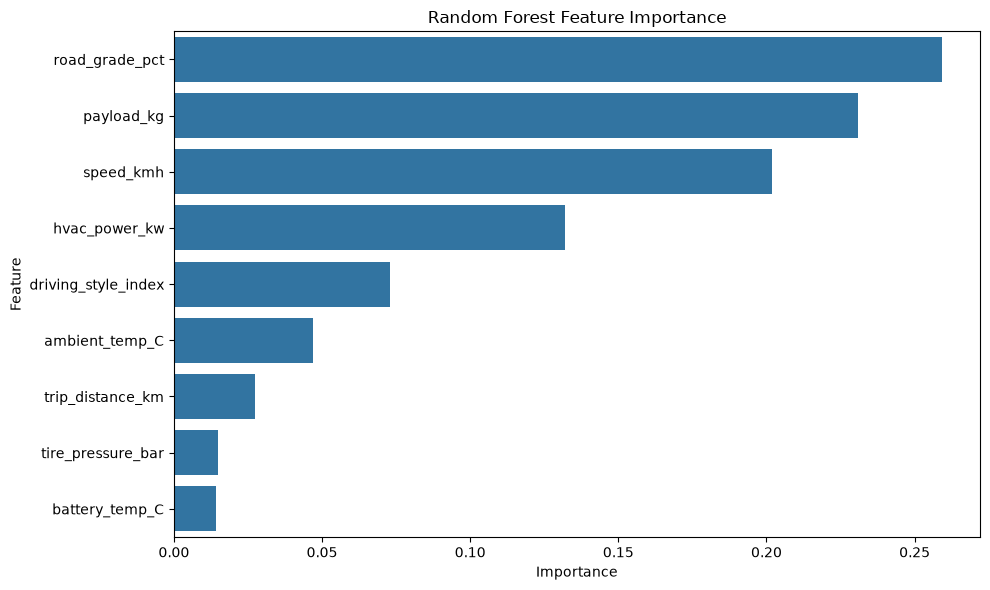

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### XGBoost + RandomizedSearchCV

In [60]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=2026,
    n_jobs=-1
)

xgb_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=2026,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

# 최적 XGBoost
xgb_model = xgb_search.best_estimator_

print("Best Parameters:")
print(xgb_search.best_params_)

print()

print(
    "Best CV RMSE:",
    -xgb_search.best_score_
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Best CV RMSE: 0.8684421105737897


In [61]:
xgb_pred = xgb_model.predict(X_test)

xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("=== XGBoost ===")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"MAE  : {xgb_mae:.4f}")
print(f"R²   : {xgb_r2:.4f}")

=== XGBoost ===
RMSE : 0.8658
MAE  : 0.6927
R²   : 0.9466


In [62]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print(xgb_importance)

               Feature  Importance
1           payload_kg    0.246885
4       road_grade_pct    0.239648
0            speed_kmh    0.187418
3        hvac_power_kw    0.138657
6  driving_style_index    0.072646
2       ambient_temp_C    0.048599
8     trip_distance_km    0.036939
7    tire_pressure_bar    0.017470
5       battery_temp_C    0.011740


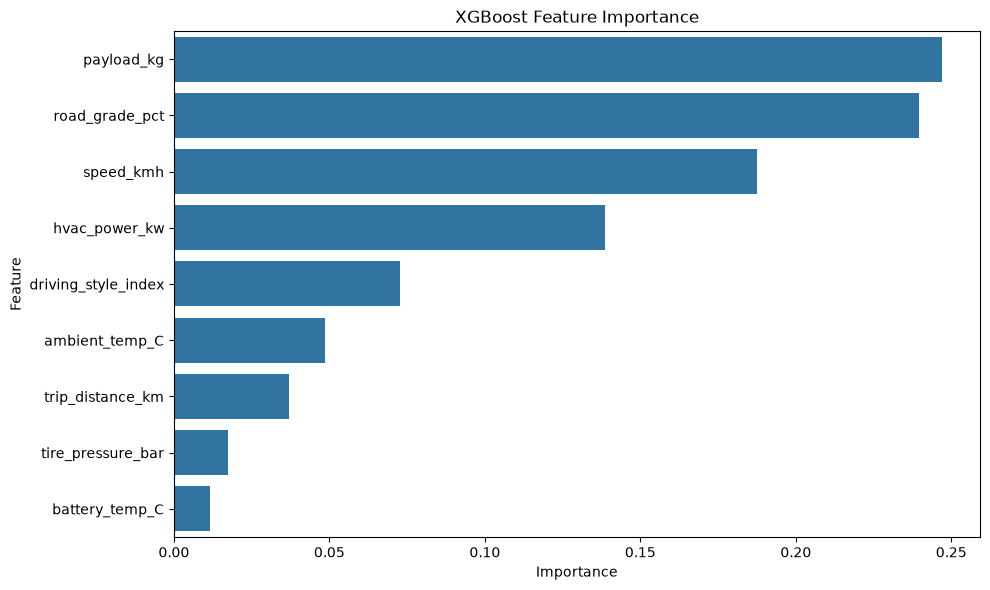

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance,
    x='Importance',
    y='Feature'
)

plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


### 세 모델 비교

In [64]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    'R2': [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison

,Model,RMSE,MAE,R2
0,Linear Regression,0.996633,0.794203,0.929264
1,Random Forest,1.193219,0.948444,0.898607
2,XGBoost,0.865813,0.692665,0.946615


### XGBoost + RandomizedSearchCV 조합이 가장 우수하므로 선택

In [70]:
best, result = recommend_speed(
    model=xgb_model,
    distance=80,
    road_grade=3.0,
    payload=100,
    ambient_temp=25,
    hvac_power=1.5,
    battery_temp=30,
    driving_style=0.3,
    tire_pressure=2.4,
    alpha=0.4
)

print(f"Recommended Speed      : {best['speed']:.0f} km/h")
print(f"Energy Consumption     : {best['consumption_per_100km']:.2f} kWh/100km")
print(f"Total Energy           : {best['total_energy']:.2f} kWh")
print(f"Travel Time            : {best['travel_time']:.2f} hour")
print(f"Travel Time            : {best['travel_time'] * 60:.1f} min")
print(f"Energy Score           : {best['energy_score']:.3f}")
print(f"Time Score             : {best['time_score']:.3f}")
print(f"Total Cost             : {best['cost']:.3f}")

Recommended Speed      : 68 km/h
Energy Consumption     : 19.76 kWh/100km
Total Energy           : 15.81 kWh
Travel Time            : 1.18 hour
Travel Time            : 70.6 min
Energy Score           : 0.353
Time Score             : 0.166
Total Cost             : 0.241


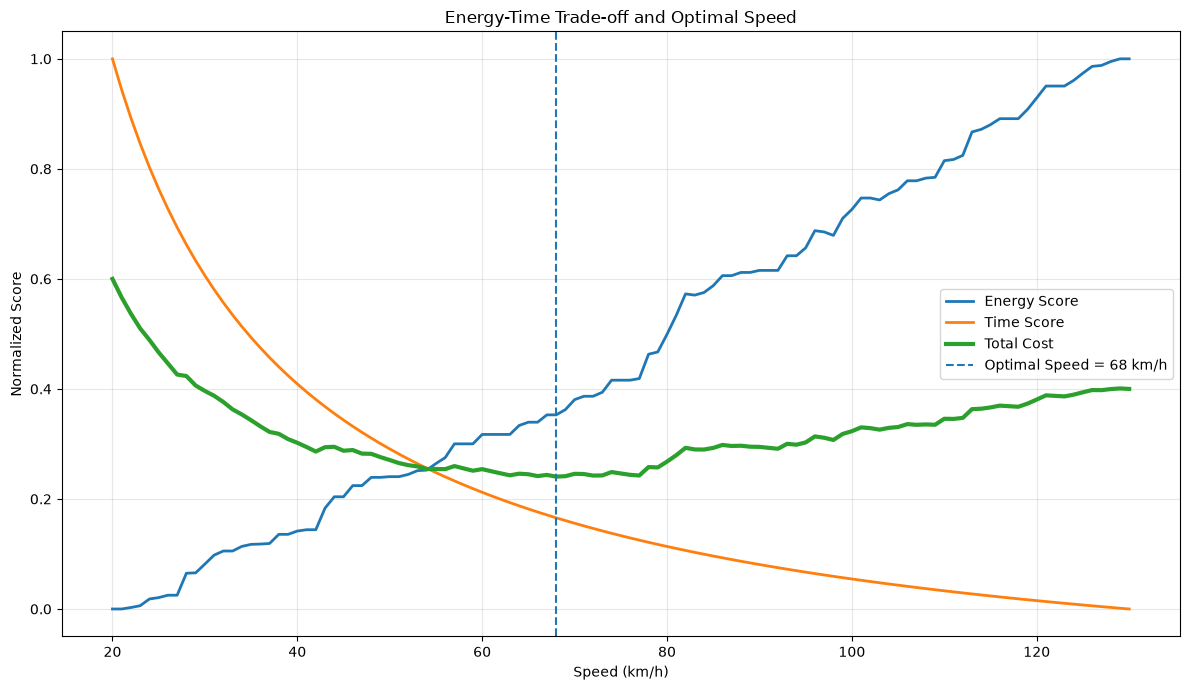

In [71]:
import matplotlib.pyplot as plt

optimal_speed = best['speed']

plt.figure(figsize=(12, 7))

plt.plot(
    result['speed'],
    result['energy_score'],
    label='Energy Score',
    linewidth=2
)

plt.plot(
    result['speed'],
    result['time_score'],
    label='Time Score',
    linewidth=2
)

plt.plot(
    result['speed'],
    result['cost'],
    label='Total Cost',
    linewidth=3
)

# 최적 속도
plt.axvline(
    optimal_speed,
    linestyle='--',
    label=f'Optimal Speed = {optimal_speed:.0f} km/h'
)

plt.xlabel('Speed (km/h)')
plt.ylabel('Normalized Score')
plt.title('Energy-Time Trade-off and Optimal Speed')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

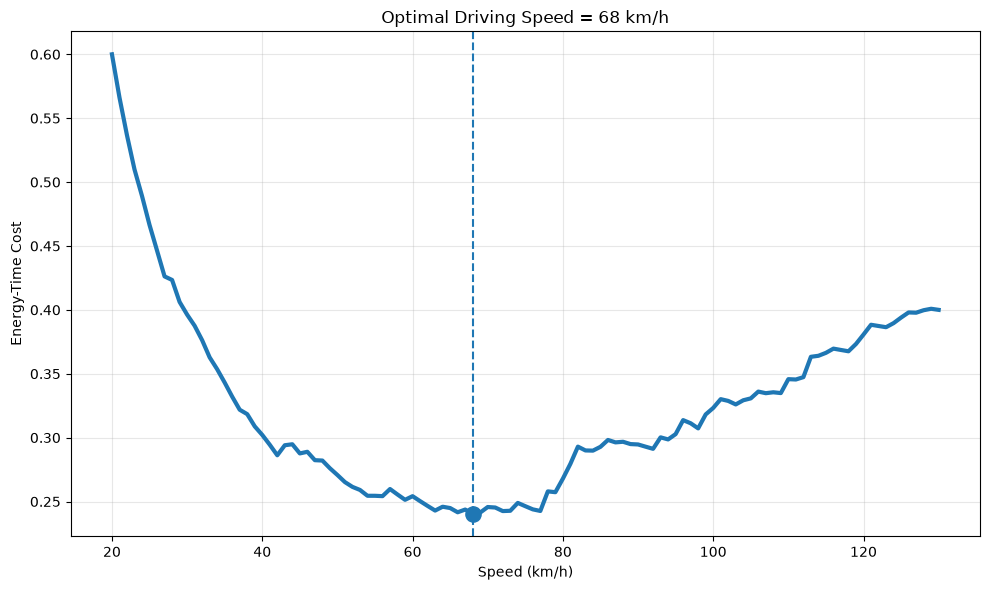

In [72]:
plt.figure(figsize=(10, 6))

plt.plot(
    result['speed'],
    result['cost'],
    linewidth=3
)

plt.scatter(
    best['speed'],
    best['cost'],
    s=120,
    zorder=5
)

plt.axvline(
    best['speed'],
    linestyle='--'
)

plt.xlabel('Speed (km/h)')
plt.ylabel('Energy-Time Cost')
plt.title(
    f'Optimal Driving Speed = {best["speed"]:.0f} km/h'
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

alpha = 0
→ 시간만 중요
→ 높은 속도 선택

alpha = 0.5
→ 시간 + 에너지 균형

alpha = 1
→ 에너지만 중요
→ 낮은 속도 선택

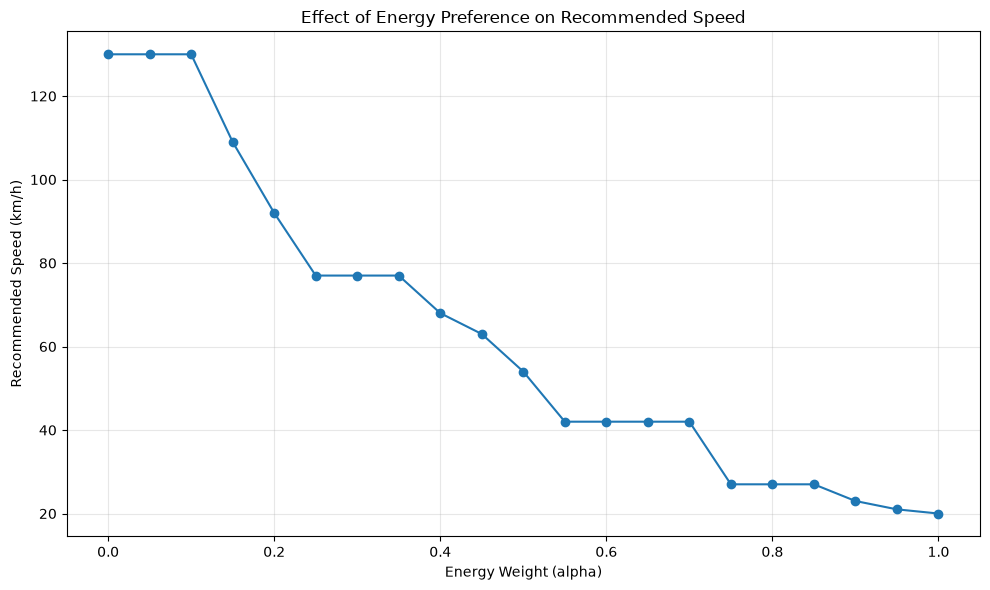

In [73]:
import numpy as np

alphas = np.arange(0, 1.01, 0.05)

optimal_speeds = []

for alpha in alphas:
    
    temp_cost = (
        alpha * result['energy_score']
        + (1 - alpha) * result['time_score']
    )
    
    idx = temp_cost.idxmin()
    
    optimal_speeds.append(
        result.loc[idx, 'speed']
    )

plt.figure(figsize=(10, 6))

plt.plot(
    alphas,
    optimal_speeds,
    marker='o'
)

plt.xlabel('Energy Weight (alpha)')
plt.ylabel('Recommended Speed (km/h)')
plt.title('Effect of Energy Preference on Recommended Speed')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()